# FakeReasoning on FakeClue — base vs fine-tuned

Four cells. Runs both checkpoints over held-out FakeClue images and prints every picture
with the ground truth, both verdicts, both confidences and both explanations.

The test set is `fakeclue_eval.json`, which the fine-tuning notebook built and then
**excluded from training** — so these are images neither run has seen.

Nothing is downloaded. If a path prints MISSING, run §1–§7 of the fine-tuning notebook
once. Budget about `2 x N x 20 s`: the default N = 20 is roughly 13 minutes.

In [1]:
# ---------------------------------------------------------------------------
# 1. Paths and the test set
# ---------------------------------------------------------------------------
import json, os, random, sys, zipfile
from collections import Counter
from pathlib import Path

PROJECT_ROOT = Path.home() / "fakereasoning"      # same value as the fine-tune notebook
SCRATCH = PROJECT_ROOT / "scratch"

N_IMAGES = 20          # per run, balanced real/fake. 20 ~ 13 min. Raise for tighter numbers.
SEED = 0               # change for a different sample of the same eval set

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["HF_HOME"] = str(SCRATCH / "huggingface")

REPO_DIR = SCRATCH / "FakeReasoning"
LLAVA_DIR = REPO_DIR / "LLaVA"
WEIGHTS_ROOT = SCRATCH / "weights"
MODEL_DIR = WEIGHTS_ROOT / "FakeReasoning"                 # the released base checkpoint

# The DINO tower reads both of these when it is constructed, so they are set before
# anything loads a model.
os.environ["DINO_PATH"] = str(REPO_DIR / "dinov2-main")
os.environ["DINO_WEIGHT"] = str(WEIGHTS_ROOT / "dinov2_vitl14_pretrain.pth")
if str(LLAVA_DIR) not in sys.path:
    sys.path.insert(0, str(LLAVA_DIR))

# The fine-tuned adapter. Point at the zip; it unpacks once and is reused after that.
ADAPTER_ZIP = PROJECT_ROOT / "fakereasoning-finetuned.zip"
ADAPTER_DIR = PROJECT_ROOT / "checkpoints" / "fakereasoning-finetuned"
if not (ADAPTER_DIR / "adapter_config.json").is_file():
    ADAPTER_DIR.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ADAPTER_ZIP) as zf:
        zf.extractall(ADAPTER_DIR.parent)
    print(f"unpacked {ADAPTER_ZIP.name}")

for name, path in [("base checkpoint", MODEL_DIR), ("adapter", ADAPTER_DIR),
                   ("LLaVA", LLAVA_DIR)]:
    print(f"  {'ok     ' if path.exists() else 'MISSING'} {name:<18} {path}")

# --- the test set ----------------------------------------------------------
# Built by §7b of the fine-tuning notebook and held out of the training mixture.
# Each record carries an absolute `image`, a ground-truth `label`, and a `cate`.
FAKECLUE_ROOT = PROJECT_ROOT / "data" / "fakeclue"
EVAL_JSON = FAKECLUE_ROOT / "fakeclue_eval.json"
assert EVAL_JSON.is_file(), (
    f"{EVAL_JSON} not found. Run §7b of the fine-tuning notebook once to build it."
)

records = json.loads(EVAL_JSON.read_text())
for r in records:                       # tolerate a moved data dir
    if not Path(r["image"]).is_file():
        r["image"] = str(FAKECLUE_ROOT / "images" / r["rel_image"])

pool = [r for r in records if Path(r["image"]).is_file()]
assert pool, "no eval images are on disk -- check FAKECLUE_ROOT"

# Balanced 50/50, so accuracy is not a report on the class ratio.
rng = random.Random(SEED)
half = N_IMAGES // 2
by_label = {lab: [r for r in pool if r["label"] == lab] for lab in ("real", "fake")}
keep = ("image", "label", "cate")           # the training target is not needed here
TEST = sum(([{k: r[k] for k in keep} for r in rng.sample(v, min(half, len(v)))]
            for v in by_label.values()), [])
rng.shuffle(TEST)

print(f"\n{len(pool)} eval images on disk -> testing {len(TEST)}")
print("  by label   ", dict(Counter(r["label"] for r in TEST)))
print("  by category", dict(Counter(r["cate"] for r in TEST)))

  ok      base checkpoint    /home/alfawzai/fakereasoning/scratch/weights/FakeReasoning
  ok      adapter            /home/alfawzai/fakereasoning/checkpoints/fakereasoning-finetuned
  ok      LLaVA              /home/alfawzai/fakereasoning/scratch/FakeReasoning/LLaVA

998 eval images on disk -> testing 20
  by label    {'real': 10, 'fake': 10}
  by category {'deepfake': 5, 'human': 3, 'animal': 12}


In [2]:
# ---------------------------------------------------------------------------
# 2. Load the base checkpoint and score it
# ---------------------------------------------------------------------------
import gc, time
import torch
from PIL import Image

from llava.constants import DEFAULT_IMAGE_TOKEN, IMAGE_TOKEN_INDEX
from llava.conversation import conv_templates
from llava.mm_utils import get_model_name_from_path, process_images, tokenizer_image_token
from llava.model.builder import load_pretrained_model

LOAD_4BIT = True          # both models, so the comparison is like for like
CONV_MODE = "llava_v1"

OFFICIAL_PROMPT = (
    "Is this image real or fake? Please describe the image, "
    "reasoning step-by-step and conclude with 'this image is real' "
    "or 'this image is fake'."
)

# The released checkpoint ends on "this image is real"; a model fine-tuned on raw
# FakeClue answers can lead with "This is a real image." instead. Both count, and the
# LAST one in the text wins, so a long answer that restates itself is scored on its
# final verdict.
VERDICT_PHRASES = {
    "real": ("this image is real", "this is a real image"),
    "fake": ("this image is fake", "this is a fake image"),
}


def extract_prediction(text):
    flat = " ".join(text.lower().split())
    at = {lab: max(flat.rfind(p) for p in ps) for lab, ps in VERDICT_PHRASES.items()}
    if at["real"] == -1 and at["fake"] == -1:
        return "unknown"
    return "real" if at["real"] > at["fake"] else "fake"


def verdict_ids(tok):
    """Token ids for the verdict words, so confidence can be read off the logits
    rather than inferred from the string the model happened to emit."""
    out = {}
    for word in ("real", "fake"):
        out[word] = sorted({enc[-1]
                            for v in (word, " " + word, word.capitalize(),
                                      " " + word.capitalize())
                            if (enc := tok.encode(v, add_special_tokens=False))})
    return out


def load_base():
    tok, mdl, proc, _ = load_pretrained_model(
        model_path=str(MODEL_DIR), model_base=None,
        model_name=get_model_name_from_path(str(MODEL_DIR)),
        load_8bit=False, load_4bit=LOAD_4BIT, device_map="auto", device="cuda",
    )
    mdl.eval()
    return tok, mdl, proc


def load_finetuned():
    from peft import PeftModel
    tok, mdl, proc = load_base()
    mdl = PeftModel.from_pretrained(mdl, str(ADAPTER_DIR))

    # Vision-tower adapters, if this checkpoint trained any. No file means the towers
    # were frozen, which is the default.
    wpath = ADAPTER_DIR / "vision_tower_weights.pt"
    state = torch.load(wpath, map_location="cpu") if wpath.is_file() else {}
    if state:
        _, unexpected = mdl.load_state_dict(state, strict=False)
        assert not unexpected, f"{len(unexpected)} vision tensors found no home"
    print(f"adapter loaded, {len(state)} vision-tower tensors")
    mdl.eval()
    return tok, mdl, proc


def run_one(path, model, tok, proc, real_ids, fake_ids, max_new_tokens=512):
    image = Image.open(path).convert("RGB")
    dtype = next(model.get_vision_tower().parameters()).dtype
    pixels = process_images([image], proc, model.config).to(model.device, dtype=dtype)

    conv = conv_templates[CONV_MODE].copy()
    conv.append_message(conv.roles[0], DEFAULT_IMAGE_TOKEN + "\n" + OFFICIAL_PROMPT)
    conv.append_message(conv.roles[1], None)
    input_ids = tokenizer_image_token(
        conv.get_prompt(), tok, IMAGE_TOKEN_INDEX, return_tensors="pt"
    ).unsqueeze(0).to(model.device)

    started = time.perf_counter()
    with torch.inference_mode():
        out = model.generate(
            inputs=input_ids, images=pixels, image_sizes=None,
            do_sample=False, num_beams=1, max_new_tokens=max_new_tokens,
            repetition_penalty=1.1, no_repeat_ngram_size=20, use_cache=True,
            output_scores=True, return_dict_in_generate=True,
        )
    text = tok.batch_decode(out.sequences, skip_special_tokens=True)[0].strip()

    # Confidence at the verdict token, before greedy decoding flattens it to a hard
    # label. A model at 0.55 and one at 0.99 emit the same string; only this tells
    # them apart, and it is what the separation number is computed from.
    p_real = None
    gen = out.sequences[0][-len(out.scores):].tolist()
    hits = [i for i, t in enumerate(gen) if t in real_ids or t in fake_ids]
    if hits:
        probs = torch.softmax(out.scores[hits[-1]][0].float(), dim=-1)
        r = float(sum(probs[i] for i in real_ids))
        f = float(sum(probs[i] for i in fake_ids))
        p_real = r / max(r + f, 1e-9)

    return {"prediction": extract_prediction(text), "explanation": text,
            "p_real": p_real, "seconds": round(time.perf_counter() - started, 1)}


def score(tag, model, tok, proc):
    ids = verdict_ids(tok)
    rows = []
    for i, rec in enumerate(TEST, 1):
        rows.append({**rec, **run_one(rec["image"], model, tok, proc,
                                      ids["real"], ids["fake"])})
        if i % 5 == 0 or i == len(TEST):
            acc = sum(x["prediction"] == x["label"] for x in rows) / len(rows)
            print(f"  {tag}: {i}/{len(TEST)}  running acc {acc:.0%}", flush=True)
    return rows


def free_gpu():
    """Drop the model and IPython's output history, which pins tensors alive and is the
    usual reason a second load runs out of memory."""
    g, ip = globals(), get_ipython()
    for name in ("model", "tokenizer", "image_processor"):
        g.pop(name, None)
    for name, value in list(g.items()):
        if isinstance(value, (torch.nn.Module, torch.Tensor)):
            g.pop(name, None)
    for attr in ("last_traceback", "last_value", "last_type", "last_exc"):
        setattr(sys, attr, None)
    ip.user_ns.get("Out", {}).clear()
    getattr(ip.history_manager, "output_hist", {}).clear()
    gc.collect(); gc.collect()
    torch.cuda.empty_cache()
    print(f"  freed, {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB allocated")


print("loading the released base checkpoint ...")
tokenizer, model, image_processor = load_base()
BASE_ROWS = score("base", model, tokenizer, image_processor)

print("\nfreeing it before the fine-tuned model loads ...")
free_gpu()

loading the released base checkpoint ...


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

/home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/alfawzai/fakereasoning/scratch/FakeReasoning/dinov2-main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


loading: dual-branch visual encoder
  base: 5/20  running acc 80%
  base: 10/20  running acc 80%
  base: 15/20  running acc 73%
  base: 20/20  running acc 70%

freeing it before the fine-tuned model loads ...
  freed, 0.01 GB allocated


In [3]:
# ---------------------------------------------------------------------------
# 3. Load the fine-tuned checkpoint and score the same images
# ---------------------------------------------------------------------------
print("loading the fine-tuned checkpoint ...")
tokenizer, model, image_processor = load_finetuned()
FT_ROWS = score("finetuned", model, tokenizer, image_processor)
print("\ndone")

loading the fine-tuned checkpoint ...


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

loading: dual-branch visual encoder
adapter loaded, 0 vision-tower tensors
  finetuned: 5/20  running acc 80%
  finetuned: 10/20  running acc 90%
  finetuned: 15/20  running acc 87%
  finetuned: 20/20  running acc 85%

done


20 held-out FakeClue images

                      base   fine-tuned     delta
-------------------------------------------------
accuracy             70.0%        85.0%    +15.0%
real recall          70.0%       100.0%    +30.0%
fake recall          70.0%        70.0%     +0.0%
separation          +0.400       +0.699    +0.299


ground truthrealdeepfakeFIXED,"basefake wrong p(real) 0.00<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY> <CAPTION> The image shows a person with long dark hair, wearing a light-colored top, against a blurred background that includes shades of pink and white. The individual appears to be in a neutral expression, looking slightly off to the side. </CAPTION> <REASONING> From low-level perspective: The lighting on the face does not match the background lighting.The skin texture appears overly smooth and lacks natural imperfections. Therefore, this image is fake. </REASONING> <CONCLUSION> This image is fake. </CONCLUSION>","fine-tunedreal correct p(real) 1.00<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY> <REASONING> The person exhibits natural skin textures with gradual tone transitions and microscopic imperfections; the nostrils have a natural asymmetric shape with pore-level detail; the eye reflection shows physically accurate light interactions in the cornea and conjunctiva; the lip texture includes visible striations and a natural moisture gradient; shadows are consistent with ambient occlusion in nasal folds and facial contours; there are micro-movements in facial muscles and natural blink patterns, indicating biological signatures. </REASONING> <CONCLUSION> This image is real. </CONCLUSION>"
ground truthrealhuman,"basereal correct p(real) 1.00<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY> <CAPTION> The image shows a religious ceremony where a cardinal, dressed in traditional papal attire including a mitre and robes, is being assisted by another individual wearing red vestments. The setting appears to be inside a church, with ornate decorations visible in the background. </CAPTION> <REASONING> From low-level perspective: The textures of clothing and skin appear natural and consistent throughout the image.The edges of objects and people are smooth and well-defined without any unnatural artifacts.The lighting and shadows are consistent with a single light source, typical of indoor photography.The image has clear details and sharpness, indicating it was captured with a good quality camera. From high-level perspective: The scene depicts a formal event involving two individuals in ceremonial attire, which is logically coherent. Therefore, this image is real. </REASONING> <CONCLUSION> This image is real. </CONCLUSION>","fine-tunedreal correct p(real) 1.00<SUMMARY> I will determine if the image is real or fake by analyzing its content and identifying forgery attributes from both low-level and high-level perspectives. I will then conclude by stating either 'this image is real' or 'this image is fake' based on my analysis. </SUMMARY> <REASONING> The textures of the person's skin, hair, and clothing are clearly defined, with no unnatural blending; the body's proportions are realistic and symmetrical, with natural alignment in the arms, legs, and head; the person's skin tone is natural, and the colors of the clothing are not overly saturated, maintaining a true-to-life appearance; all details, such as facial features and the muscles in the body, are sharp and clear, with no visible artifacts or blurriness; the image maintains a high level of clarity, with no visible noise, distortion, or blurring in the foreground or background; the elements with
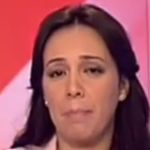
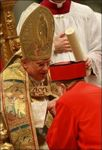
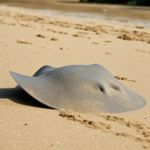
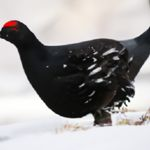
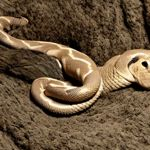
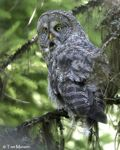
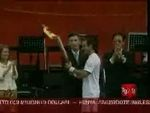
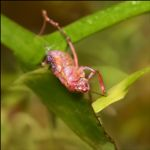
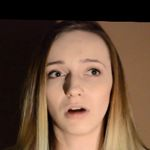
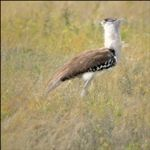
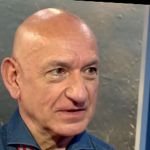
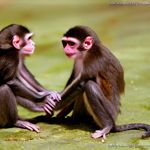
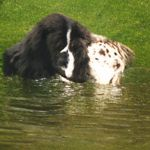
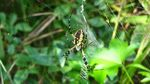
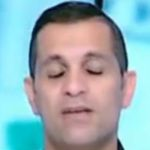
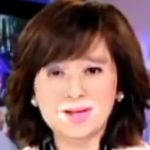
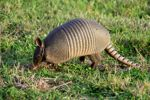
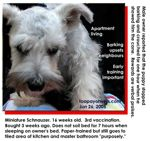
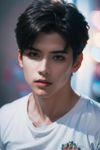
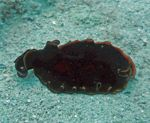


wrote /home/alfawzai/fakereasoning/fakeclue_mini_results.json


In [4]:
# ---------------------------------------------------------------------------
# 4. Side by side: image, ground truth, both verdicts, both explanations
# ---------------------------------------------------------------------------
import base64, html
from io import BytesIO
from IPython.display import HTML, display


def summarise(rows, name):
    n = len(rows)
    hit = [r["prediction"] == r["label"] for r in rows]
    by = lambda lab: [r for r in rows if r["label"] == lab]
    rec = lambda lab: (sum(r["prediction"] == lab for r in by(lab))
                       / max(1, len(by(lab))))
    scored = [r for r in rows if r["p_real"] is not None]
    mean = lambda lab: (sum(r["p_real"] for r in scored if r["label"] == lab)
                        / max(1, sum(1 for r in scored if r["label"] == lab)))
    return {"model": name, "accuracy": sum(hit) / n,
            "real recall": rec("real"), "fake recall": rec("fake"),
            "separation": mean("real") - mean("fake"),
            "mean seconds": sum(r["seconds"] for r in rows) / n}


BASE_STATS = summarise(BASE_ROWS, "base")
FT_STATS = summarise(FT_ROWS, "fine-tuned")

print(f"{len(TEST)} held-out FakeClue images\n")
print(f"{'':<16}{'base':>10}{'fine-tuned':>13}{'delta':>10}")
print("-" * 49)
for key in ("accuracy", "real recall", "fake recall", "separation"):
    lo, hi = BASE_STATS[key], FT_STATS[key]
    # Separation is a difference of probabilities, not a rate -- printing it as a
    # percentage would invite comparing it against the accuracy column.
    unit = ".3f" if key == "separation" else ".1%"
    sign = "+" if key == "separation" else ""
    print(f"{key:<16}{lo:>{sign}10{unit}}{hi:>{sign}13{unit}}{hi - lo:>+10{unit}}")

THUMB = 150


def thumb(path):
    img = Image.open(path).convert("RGB")
    img.thumbnail((THUMB, THUMB))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=80)
    return f'<img src="data:image/jpeg;base64,{base64.b64encode(buf.getvalue()).decode()}">'


def panel(row, title):
    ok = row["prediction"] == row["label"]
    conf = "" if row["p_real"] is None else f' &nbsp;<span style="color:#666;font-weight:400">p(real) {row["p_real"]:.2f}</span>'
    return (
        f'<td style="vertical-align:top;padding:10px 14px;width:42%;'
        f'border-left:1px solid #e0e0e0">'
        f'<div style="font-size:11px;letter-spacing:.08em;color:#888;'
        f'text-transform:uppercase">{title}</div>'
        f'<div style="font-size:15px;font-weight:700;margin:2px 0 8px;'
        f'color:{"#137333" if ok else "#c5221f"}">{row["prediction"]}'
        f' {"correct" if ok else "wrong"}{conf}</div>'
        f'<div style="font-size:12px;line-height:1.5;white-space:pre-wrap;'
        f'color:#333;max-height:280px;overflow:auto">'
        f'{html.escape(row["explanation"])}</div></td>'
    )


blocks = []
for br, fr in zip(BASE_ROWS, FT_ROWS):
    changed = ("" if br["prediction"] == fr["prediction"]
               else ("FIXED" if fr["prediction"] == fr["label"] else "BROKE"))
    tag = ("" if not changed else
           f'<div style="margin-top:8px;font-size:11px;font-weight:700;'
           f'color:{"#137333" if changed == "FIXED" else "#c5221f"}">{changed}</div>')
    blocks.append(
        '<table style="border-collapse:collapse;width:100%;margin-bottom:18px;'
        'border:1px solid #e0e0e0;font-family:system-ui,sans-serif"><tr>'
        f'<td style="vertical-align:top;padding:10px;width:16%">{thumb(br["image"])}'
        f'<div style="margin-top:6px;font-size:11px;color:#888">ground truth</div>'
        f'<div style="font-size:15px;font-weight:700">{br["label"]}</div>'
        f'<div style="font-size:11px;color:#888;margin-top:4px">{br["cate"]}</div>'
        f'{tag}</td>'
        + panel(br, "base") + panel(fr, "fine-tuned") + '</tr></table>'
    )

display(HTML("".join(blocks)))

out_path = PROJECT_ROOT / "fakeclue_mini_results.json"
out_path.write_text(json.dumps(
    {"n": len(TEST), "base": BASE_STATS, "finetuned": FT_STATS,
     "rows": [{"image": br["image"], "truth": br["label"], "cate": br["cate"],
               "base": br["prediction"], "base_p_real": br["p_real"],
               "finetuned": fr["prediction"], "finetuned_p_real": fr["p_real"],
               "base_explanation": br["explanation"],
               "finetuned_explanation": fr["explanation"]}
              for br, fr in zip(BASE_ROWS, FT_ROWS)]}, indent=2))
print(f"\nwrote {out_path}")